# Introduction to Deep Learning with PyTorch
## Skin Lesion Classification – A Step-by-Step Walkthrough

---

### What You Will Learn

| Topic | Description |
|---|---|
| PyTorch Basics | Tensors, devices (CPU vs GPU), and `nn.Module` |
| Building CNNs | Writing ConvNets from scratch two different ways |
| Transfer Learning | Fine-tuning a pre-trained ResNet-18 |
| Custom Datasets | Writing a `torch.utils.data.Dataset` for image folders |
| Training Loop | Full train / validate loop with loss and accuracy tracking |
| Visualisation | Plotting learning curves with Matplotlib |

---

### Background: What is PyTorch?

**PyTorch** is an open-source deep learning framework developed by Meta AI.  
Its two key features are:

1. **Dynamic computation graphs** – the graph is built on-the-fly each forward pass, making debugging easy.
2. **Autograd** – automatic differentiation.  PyTorch records every operation on a tensor so it can compute gradients automatically during `loss.backward()`.

### The Core Training Loop

Every supervised deep-learning training run follows this cycle:

```
for each batch:
    1. Forward pass   → model produces predictions
    2. Compute loss   → compare predictions with ground-truth labels
    3. Backward pass  → compute gradients w.r.t. all parameters
    4. Optimizer step → update parameters to reduce the loss
```

The loss objective we minimise here is **Cross-Entropy** for multi-class classification:

$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{p}_c)$$

where $y_c$ is the one-hot label and $\hat{p}_c$ is the predicted probability for class $c$.

---
## 1. Setup — Imports & Device Selection

PyTorch computations can run on:
- **CPU** – always available, but slow for large models.
- **GPU (CUDA)** – 10–100× faster for matrix operations; requires an NVIDIA GPU.

`torch.device("cuda" if torch.cuda.is_available() else "cpu")` selects the GPU automatically if one is present, and falls back to CPU otherwise.

Every tensor and every model must be **on the same device** — we move them with `.to(device)`.

In [1]:
import torch
import torch.nn as nn           # neural-network building blocks (layers, losses)
import torch.optim as optim     # optimizers (Adam, SGD, …)
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms   # image datasets & augmentation helpers

# ── Device selection ─────────────────────────────────────────────────────────
# This single line makes your code portable: it automatically uses the GPU
# when available, and silently falls back to CPU on machines without one.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## 2. Building a CNN — Method 1: Explicit Layer Attributes (`SkinConvNetV1`)

### Convolutional Neural Networks (CNNs)

CNNs are the dominant architecture for image classification.  
They learn **spatial feature detectors** (edges → textures → shapes → objects) by sliding small filters across the image.

Key operations:

| Layer | Role |
|---|---|
| `Conv2d(in, out, k)` | Applies `out` learnable filters of size `k×k` to the input |
| `BatchNorm2d` | Normalises activations per channel → stabilises & speeds up training |
| `ReLU` | Non-linear activation: $f(x) = \max(0, x)$ — adds representational power |
| `MaxPool2d(2)` | Downsamples by 2 by keeping the max value in each 2×2 window → reduces spatial size |
| `AdaptiveAvgPool2d(4)` | Regardless of input size, outputs a fixed 4×4 feature map |
| `Linear` | Fully-connected layer for the final classification head |
| `Dropout(p)` | Randomly zeroes `p` fraction of neurons during training — reduces overfitting |

### Spatial Size Formula

After a convolution with `padding=1` on an `N×N` image: output is still `N×N`.  
After `MaxPool2d(2)`: output becomes `N/2 × N/2`.

### Method 1 – Explicit attributes

Each layer is stored as a named attribute of the class (e.g. `self.conv1`).  
The `forward()` method manually chains them, giving you full visibility and control.


In [ ]:
# ── SkinConvNetV1 – explicit layer attributes, no nn.Sequential ───────────────
class SkinConvNetV1(nn.Module):
    """
    A 3-block ConvNet where every layer is defined as a named attribute.

    Architecture summary (input: 3×128×128):
        Conv1  → BN → ReLU → MaxPool  : 3×128×128  →  32×64×64
        Conv2  → BN → ReLU → MaxPool  : 32×64×64   →  64×32×32
        Conv3  → BN → ReLU → AvgPool  : 64×32×32   → 128×4×4
        Flatten → FC1 → ReLU → Dropout → FC2        : 2048 → 256 → num_classes
    """

    def __init__(self, num_classes: int = 5):
        super().__init__()   # always call super().__init__() first!

        # ── Convolutional blocks ──────────────────────────────────────────────
        # Block 1: learns low-level features (edges, colours)
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # RGB → 32 feature maps
        self.bn1   = nn.BatchNorm2d(32)

        # Block 2: learns mid-level features (corners, blobs)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 → 64 feature maps
        self.bn2   = nn.BatchNorm2d(64)

        # Block 3: learns high-level features (textures, lesion patterns)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 → 128 feature maps
        self.bn3   = nn.BatchNorm2d(128)

        # Shared pooling layers
        self.pool    = nn.MaxPool2d(2)           # halves spatial dimensions
        self.avgpool = nn.AdaptiveAvgPool2d(4)   # outputs exactly 4×4 regardless of input size
        self.relu    = nn.ReLU(inplace=True)     # inplace=True saves memory

        # ── Classification head ───────────────────────────────────────────────
        # 128 channels × 4×4 spatial = 2048 features fed into FC layers
        self.flatten = nn.Flatten()
        self.fc1     = nn.Linear(128 * 4 * 4, 256)  # 2048 → 256
        self.dropout = nn.Dropout(0.5)               # drop 50% of neurons during training
        self.fc2     = nn.Linear(256, num_classes)   # 256 → num_classes (raw logits)

    def forward(self, x):
        """
        Defines how data flows through the network.
        PyTorch calls this method automatically when you do: model(input)
        """
        # Block 1: convolve → normalise → activate → pool
        x = self.relu(self.bn1(self.conv1(x)))   # 3×128×128  → 32×128×128
        x = self.pool(x)                          #            → 32×64×64

        # Block 2
        x = self.relu(self.bn2(self.conv2(x)))   # 32×64×64   → 64×64×64
        x = self.pool(x)                          #            → 64×32×32

        # Block 3 (uses adaptive average pooling instead of max-pool)
        x = self.relu(self.bn3(self.conv3(x)))   # 64×32×32   → 128×32×32
        x = self.avgpool(x)                       #            → 128×4×4

        # Classifier
        x = self.flatten(x)                       # 128×4×4    → 2048
        x = self.relu(self.fc1(x))               # 2048       → 256
        x = self.dropout(x)                       # regularisation
        x = self.fc2(x)                           # 256        → num_classes (logits)
        return x

### 2.1 Sanity Check — Forward Pass with a Random Tensor

Before hooking up real data, verify the model runs without errors and produces the expected output shape.  
- Input shape: `(batch_size, channels, height, width)` = `(1, 3, 128, 128)`  
- Expected output shape: `(1, num_classes)` = `(1, 5)` — five raw **logits**, one per class.

In [ ]:
# Instantiate model (not yet on GPU — this is just a quick shape check)
model1 = SkinConvNetV1(num_classes=5)

# Create a fake batch of 1 random RGB image at 128×128
rand_img = torch.randn(1, 3, 128, 128)  # shape: [batch=1, C=3, H=128, W=128]
print("Input shape :", rand_img.shape)

# Run the forward pass (no gradients needed for a simple shape test)
with torch.no_grad():
    output = model1(rand_img)

print("Output (raw logits):", output)   # 5 numbers — one score per class
print("Output shape       :", output.shape)  # should be torch.Size([1, 5])

Input shape : torch.Size([1, 3, 128, 128])
Output (raw logits): tensor([[-0.0375, -0.0636,  0.0259, -0.0654]])
Output shape       : torch.Size([1, 4])


---
## 3. Building a CNN — Method 2: `nn.Sequential` (`SkinConvNetV2`)

### Why `nn.Sequential`?

`nn.Sequential` lets you stack layers into a reusable container where the **output of each layer feeds directly into the next**.  
It is ideal when there are no skip connections or branching paths.

**Pros vs explicit attributes:**
- Cleaner, less boilerplate code  
- The `forward()` method shrinks to two lines  

**Cons:**
- Less flexibility for complex architectures (e.g., ResNet residual connections)

This version adds a **4th conv block** (128 → 256 channels), giving the model more capacity to learn fine-grained features.

In [ ]:
# ── SkinConvNetV2 – 4-block ConvNet using nn.Sequential ───────────────────────
class SkinConvNetV2(nn.Module):
    """
    Deeper 4-block ConvNet using nn.Sequential containers.

    Architecture summary (input: 3×128×128):
        Block 1: Conv(3→32)   → BN → ReLU → MaxPool  →  32×64×64
        Block 2: Conv(32→64)  → BN → ReLU → MaxPool  →  64×32×32
        Block 3: Conv(64→128) → BN → ReLU → MaxPool  → 128×16×16
        Block 4: Conv(128→256)→ BN → ReLU → AvgPool  → 256×4×4
        Classifier: Flatten → FC(4096→512) → ReLU → Dropout → FC(512→C)
    """

    def __init__(self, num_classes: int = 5):
        super().__init__()

        # ── Feature extractor (convolutional backbone) ────────────────────────
        # nn.Sequential chains layers: output_i becomes input_{i+1} automatically
        self.features = nn.Sequential(
            # Block 1 – detect edges and basic colour gradients
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 3×128×128 → 32×128×128
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # → 32×64×64

            # Block 2 – detect corners, textures at medium scale
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # → 64×64×64
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # → 64×32×32

            # Block 3 – detect complex patterns (lesion borders, pigment)
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # → 128×32×32
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                               # → 128×16×16

            # Block 4 – high-level semantic features
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# → 256×16×16
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(4),                       # → 256×4×4 (fixed output)
        )

        # ── Classification head ───────────────────────────────────────────────
        # 256 channels × 4×4 = 4096 features
        self.classifier = nn.Sequential(
            nn.Flatten(),                                  # 256×4×4 → 4096
            nn.Linear(256 * 4 * 4, 512),                   # 4096 → 512
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),                               # regularisation
            nn.Linear(512, num_classes),                   # 512 → num_classes logits
        )

    def forward(self, x):
        x = self.features(x)      # pass through all conv blocks
        x = self.classifier(x)    # pass through the FC head
        return x                  # returns raw logits (no softmax — CrossEntropyLoss handles that)

---
## 4. Transfer Learning with a Pre-trained ResNet-18

### What is Transfer Learning?

Training a deep CNN from scratch requires enormous amounts of data and compute.  
**Transfer learning** reuses a model that was pre-trained on a large dataset (ImageNet — 1.2M images, 1000 classes) and adapts it to your smaller task.

### Why Does It Work?

The early convolutional layers of any image model learn **general-purpose detectors** (edges, colours, gradients).  
Only the final layers are task-specific.  
By replacing just the final fully-connected layer, we keep all the learned feature extractors and only train a new classification head for our 4 skin-lesion classes.

### ResNet-18 Architecture

ResNet (**Residual Network**) introduced **skip connections** that add the input of a block directly to its output:

$$\text{output} = F(x) + x$$

This solves the **vanishing gradient problem**, enabling very deep networks to train effectively.  
ResNet-18 has 18 layers and ~11 million parameters.

### Fine-tuning Strategy Used Here

- All layers are **trainable** (full fine-tuning)  
- Only the final classification layer is **replaced** to output 4 classes instead of 1000  
- The pre-trained weights give a much better starting point than random initialisation

In [ ]:
from torchvision import models

# ── ResNet-18 fine-tuned for skin-lesion classification ───────────────────────
class SkinLesionResNet(nn.Module):
    """
    Wraps torchvision's ResNet-18 and replaces its classifier head.

    Strategy:
        1. Load ResNet-18 with ImageNet pre-trained weights.
        2. Replace the final FC layer (1000 outputs → num_classes).
        3. All layers remain trainable (full fine-tuning).
    """

    def __init__(self, num_classes: int = 5):
        super().__init__()

        # Load architecture + ImageNet weights (downloads on first run, ~45 MB)
        weights  = models.ResNet18_Weights.DEFAULT
        backbone = models.resnet18(weights=weights)

        # The original final layer outputs 1000 classes — we swap it out
        in_features  = backbone.fc.in_features          # 512 for ResNet-18
        backbone.fc  = nn.Linear(in_features, num_classes)  # now outputs num_classes logits

        # Store the whole modified backbone as a single attribute
        self.model = backbone

    def forward(self, x):
        # Simply delegate to the backbone — ResNet handles the rest
        return self.model(x)

---
## 5. Custom Dataset — `SkinLesionDataset`

### PyTorch Dataset API

Any custom dataset must subclass `torch.utils.data.Dataset` and implement **two methods**:

| Method | Purpose |
|---|---|
| `__len__(self)` | Returns the total number of samples |
| `__getitem__(self, idx)` | Loads and returns the sample at position `idx` |

The `DataLoader` calls these methods behind the scenes to build mini-batches.

### Folder Structure Expected

```
SkinLesions/
├── melanoma/
│   ├── img001.jpg
│   └── img002.jpg
├── nevus/
│   └── img003.jpg
└── ...
```

Each **subfolder name** is treated as a class label.  
The class index mapping (`class_to_idx`) is built alphabetically.

### Built-in Train / Val / Test Split

Rather than maintaining separate folder trees, this dataset performs the split **inside the constructor** using a fixed random seed, ensuring reproducibility.  
All three dataset objects (train, val, test) are instantiated from the same root folder — the constructor determines which images each split sees.

> **Why fix the seed?** Without a fixed seed the split is different every run, making results incomparable across experiments.

In [6]:
import os
import random
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ── Custom Dataset ─────────────────────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """
    Loads images from a class-labelled folder tree and splits them into
    train / val / test subsets using a deterministic shuffle.

    Parameters
    ----------
    root        : path to the root folder containing one sub-folder per class
    split       : which subset to return — "train", "val", or "test"
    train_ratio : fraction of data for training   (default 70%)
    val_ratio   : fraction of data for validation (default 15%)
    transform   : torchvision transform to apply to each image
    seed        : random seed for reproducible shuffling
    """

    def __init__(
        self,
        root: str,
        split: str = "train",
        train_ratio: float = 0.70,
        val_ratio:   float = 0.15,
        transform=None,
        seed: int = 42,
    ):
        assert split in ("train", "val", "test"), "split must be 'train', 'val', or 'test'"
        self.transform = transform

        # ── Step 1: Collect all image paths and derive class labels ───────────
        # glob(root/*/*) collects every file one level below the class folders
        paths       = glob(os.path.join(root, "*", "*"))
        label_names = [os.path.basename(os.path.dirname(p)) for p in paths]  # parent folder = class name

        # Build sorted class list and mapping: class_name → integer index
        self.classes      = sorted(set(label_names))              # e.g. ["mel", "nev", "scc", "bcc"]
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        # Map each image path to its integer class index
        int_labels = [self.class_to_idx[lbl] for lbl in label_names]

        # ── Step 2: Shuffle all images with a fixed seed ──────────────────────
        # Zip paths and labels together so they stay aligned during shuffle
        data = list(zip(paths, int_labels))
        random.seed(seed)     # fix seed for reproducibility
        random.shuffle(data)
        all_paths, all_labels = zip(*data)   # unzip back into two tuples

        # ── Step 3: Compute split boundaries ─────────────────────────────────
        num_total = len(all_paths)
        num_train = int(train_ratio * num_total)          # e.g. 70% of total
        num_val   = int(val_ratio   * num_total)          # e.g. 15% of total
        # test gets the remainder: (1 - 0.70 - 0.15) = 15%

        # Assign the appropriate slice to this dataset instance
        if split == "train":
            self.file_paths = list(all_paths[:num_train])
            self.labels     = list(all_labels[:num_train])
        elif split == "val":
            self.file_paths = list(all_paths[num_train : num_train + num_val])
            self.labels     = list(all_labels[num_train : num_train + num_val])
        else:  # test
            self.file_paths = list(all_paths[num_train + num_val :])
            self.labels     = list(all_labels[num_train + num_val :])

    # ── Required Dataset methods ──────────────────────────────────────────────

    def __len__(self):
        """Returns the number of samples in this split."""
        return len(self.file_paths)

    def __getitem__(self, idx):
        """
        Loads the image at position idx, applies transforms, and returns
        a (tensor, label) pair.
        """
        img   = Image.open(self.file_paths[idx]).convert("RGB")  # load as PIL image, force RGB
        label = self.labels[idx]                                  # integer class index

        if self.transform:
            img = self.transform(img)   # apply resize, ToTensor, Normalize, etc.

        return img, label   # DataLoader collects these into batches automatically

---
## 6. Data Transforms

### Why Do We Need Transforms?

PyTorch models expect a **torch.Tensor** of a fixed size, not a raw PIL image.  
`transforms.Compose` chains multiple operations into a single callable pipeline.

| Transform | What it Does | Why |
|---|---|---|
| `Resize((H, W))` | Resizes all images to the same size | CNNs require fixed-size inputs |
| `ToTensor()` | Converts PIL image (H×W×C, uint8 0–255) → Tensor (C×H×W, float 0–1) | PyTorch works with tensors |
| `Normalize(mean, std)` | Subtracts mean, divides by std channel-wise | Centres features, improves training stability |

### ImageNet Normalisation Values

The mean and standard deviation below were computed over the entire ImageNet dataset and are the **standard values** used with any pre-trained torchvision model:

$$\hat{x}_c = \frac{x_c - \mu_c}{\sigma_c}$$

| Channel | Mean ($\mu$) | Std ($\sigma$) |
|---|---|---|
| Red | 0.485 | 0.229 |
| Green | 0.456 | 0.224 |
| Blue | 0.406 | 0.225 |

> **Tip:** When using a model trained from scratch (not pre-trained), it is better to compute mean/std from your own training set.

In [7]:
# ── Image size and normalisation constants ────────────────────────────────────
IMG_SIZE = 128   # resize all images to 128×128 pixels

# ImageNet channel-wise statistics (standard values for pre-trained torchvision models)
_mean = [0.485, 0.456, 0.406]   # per-channel mean  [R, G, B]
_std  = [0.229, 0.224, 0.225]   # per-channel std   [R, G, B]

# ── Evaluation / inference transform ─────────────────────────────────────────
# Used for validation and test sets — only geometry + normalisation, NO random augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # force all images to the same spatial size
    transforms.ToTensor(),                    # PIL (H×W×C uint8) → Tensor (C×H×W float [0,1])
    transforms.Normalize(_mean, _std),        # standardise per channel
])

# ── Optional: training augmentation transform (improves generalisation) ───────
# Data augmentation artificially increases dataset diversity by applying
# random but realistic-looking distortions to the training images.
# The val/test transforms should NOT include random operations.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),        # 50% chance to flip left-right
    transforms.RandomVerticalFlip(),          # skin lesions can appear at any orientation
    transforms.RandomRotation(15),            # rotate up to ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # mild colour variation
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(_mean, _std),
])

print(f"Images will be resized to {IMG_SIZE}×{IMG_SIZE}")
print("Training transform includes augmentation (flip, rotate, colour jitter)")
print("Eval transform is deterministic (resize + normalise only)")

Images will be resized to 128×128
Training transform includes augmentation (flip, rotate, colour jitter)
Eval transform is deterministic (resize + normalise only)


---
## 7. Creating Datasets and DataLoaders

### Dataset vs DataLoader

| | `Dataset` | `DataLoader` |
|---|---|---|
| **Role** | Knows how to get a single `(image, label)` pair | Batches, shuffles, and parallelises loading |
| **Key methods** | `__len__`, `__getitem__` | Iterable: `for batch in loader` |
| **Parallelism** | Single-threaded | `num_workers` background threads |

### Important DataLoader Parameters

| Parameter | Meaning |
|---|---|
| `batch_size` | How many images per gradient update |
| `shuffle=True` | Randomise order each epoch (training only) |
| `num_workers` | CPU threads loading data in parallel (0 = main thread) |
| `pin_memory=True` | Pins CPU tensors in memory for faster GPU transfer |

> **Rule of thumb:** `shuffle=True` on training set; `shuffle=False` on val/test (order doesn't matter for evaluation).

In [8]:
# ── Path to the skin-lesion image dataset ─────────────────────────────────────
DATA_ROOT = "/blue/bme6938/share/Datasets/SkinLesions"

# ── Instantiate the three splits ──────────────────────────────────────────────
# All three use the same root and seed=42, so the shuffled order is identical
# and each image lands in exactly one split (no overlap).
train_ds = SkinLesionDataset(root=DATA_ROOT, split="train", transform=train_transform, seed=42)
val_ds   = SkinLesionDataset(root=DATA_ROOT, split="val",   transform=eval_transform,  seed=42)
test_ds  = SkinLesionDataset(root=DATA_ROOT, split="test",  transform=eval_transform,  seed=42)

# Read the number of classes from the training set
num_classes = len(train_ds.classes)

# Print a quick summary of the split sizes
print(f"Classes  : {train_ds.classes}")
print(f"Train    : {len(train_ds):,} images")
print(f"Val      : {len(val_ds):,} images")
print(f"Test     : {len(test_ds):,} images")
print(f"Total    : {len(train_ds)+len(val_ds)+len(test_ds):,} images")

Classes  : ['acne', 'eksim', 'herpes', 'panu', 'rosacea']
Train    : 1,045 images
Val      : 224 images
Test     : 225 images
Total    : 1,494 images


In [9]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 10   # process 10 images per gradient update
                  # larger batches → faster training but more GPU memory

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,          # randomise order every epoch (crucial for training)
    num_workers=2,         # 2 background threads pre-load the next batch
    pin_memory=True,       # speeds up CPU→GPU memory transfer
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,         # order doesn't matter for evaluation
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

# Verify a single batch shape
imgs_sample, lbls_sample = next(iter(train_loader))
print(f"Batch image tensor shape : {imgs_sample.shape}")   # [10, 3, 128, 128]
print(f"Batch label tensor shape : {lbls_sample.shape}")   # [10]
print(f"Label values in batch    : {lbls_sample.tolist()}")

Batch image tensor shape : torch.Size([10, 3, 128, 128])
Batch label tensor shape : torch.Size([10])
Label values in batch    : [4, 0, 1, 3, 2, 1, 2, 2, 3, 2]


---
## 8. Training Loop

### Choosing an Optimizer

**Adam** (Adaptive Moment Estimation) is the most commonly used optimizer for deep learning.  
It maintains per-parameter learning rates that adapt based on the first and second moments of gradients:

$$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

- $\hat{m}_t$ — bias-corrected first moment (mean of gradients)
- $\hat{v}_t$ — bias-corrected second moment (uncentered variance)
- $\eta$ — learning rate (typically `1e-3` to `1e-4`)

### The Per-Epoch Workflow

```
Training phase (model.train()):
    for each mini-batch:
        1. Move data to device
        2. Zero out old gradients   ← optimizer.zero_grad()
        3. Forward pass             ← outputs = model(imgs)
        4. Compute loss             ← loss = criterion(outputs, labels)
        5. Backward pass            ← loss.backward()
        6. Update weights           ← optimizer.step()

Validation phase (model.eval() + torch.no_grad()):
    for each mini-batch:
        1. Forward pass only — no gradients needed
        2. Accumulate loss and correct predictions
```

> **`model.train()` vs `model.eval()`:** These switch Dropout (active only in train mode) and BatchNorm (uses running stats in eval mode) to the correct behaviour.

In [10]:
# ── Model, loss function, and optimizer ───────────────────────────────────────

# Instantiate the model and move it to the selected device (CPU or GPU)
model = SkinConvNetV2(num_classes=num_classes)
model.to(device)   # must be called before creating the optimizer!

# CrossEntropyLoss = LogSoftmax + NLLLoss combined
# It expects raw logits (NOT softmax probabilities) as input
criterion = nn.CrossEntropyLoss()

# Adam optimizer with a learning rate of 0.001
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ── History dict — stores per-epoch metrics for plotting ─────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):

    # ══════════════════════════════════════════════════════════════════════════
    # TRAINING PHASE
    # ══════════════════════════════════════════════════════════════════════════
    model.train()   # enables Dropout and BatchNorm training behaviour
    train_loss, train_correct = 0.0, 0

    for imgs, lbls in train_loader:
        # 1. Move tensors to device (GPU if available)
        imgs, lbls = imgs.to(device), lbls.to(device)

        # 2. Clear gradients from the previous step
        #    (PyTorch accumulates gradients by default — we must reset them)
        optimizer.zero_grad()

        # 3. Forward pass: compute predictions
        outputs = model(imgs)             # shape: [batch_size, num_classes]

        # 4. Compute loss (CrossEntropyLoss applies softmax internally)
        loss = criterion(outputs, lbls)

        # 5. Backward pass: compute gradients for all learnable parameters
        loss.backward()

        # 6. Update weights in the direction that reduces the loss
        optimizer.step()

        # Accumulate stats for this epoch
        train_loss    += loss.item() * imgs.size(0)                   # weighted by batch size
        train_correct += (outputs.argmax(1) == lbls).sum().item()     # count correct predictions

    # Average loss and accuracy over all training samples
    train_loss /= len(train_loader.dataset)
    train_acc   = train_correct / len(train_loader.dataset)

    # ══════════════════════════════════════════════════════════════════════════
    # VALIDATION PHASE
    # ══════════════════════════════════════════════════════════════════════════
    model.eval()   # disables Dropout; BatchNorm uses running statistics
    val_loss, val_correct = 0.0, 0

    with torch.no_grad():   # no_grad disables gradient tracking → saves memory & compute
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs    = model(imgs)
            loss       = criterion(outputs, lbls)

            val_loss    += loss.item() * imgs.size(0)
            val_correct += (outputs.argmax(1) == lbls).sum().item()

    val_loss /= len(val_loader.dataset)
    val_acc   = val_correct / len(val_loader.dataset)

    # ── Record metrics ────────────────────────────────────────────────────────
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.3f} | "
          f"Val   Loss: {val_loss:.4f}  Acc: {val_acc:.3f}")

Epoch 01/50 | Train Loss: 1.6364  Acc: 0.341 | Val   Loss: 1.3217  Acc: 0.420
Epoch 02/50 | Train Loss: 1.3544  Acc: 0.423 | Val   Loss: 1.2209  Acc: 0.455
Epoch 03/50 | Train Loss: 1.3454  Acc: 0.406 | Val   Loss: 1.2852  Acc: 0.402
Epoch 04/50 | Train Loss: 1.3014  Acc: 0.435 | Val   Loss: 1.2073  Acc: 0.482
Epoch 05/50 | Train Loss: 1.2771  Acc: 0.434 | Val   Loss: 1.1630  Acc: 0.460
Epoch 06/50 | Train Loss: 1.2344  Acc: 0.478 | Val   Loss: 1.1546  Acc: 0.473
Epoch 07/50 | Train Loss: 1.1974  Acc: 0.493 | Val   Loss: 1.1258  Acc: 0.487
Epoch 08/50 | Train Loss: 1.2217  Acc: 0.497 | Val   Loss: 1.0883  Acc: 0.500
Epoch 09/50 | Train Loss: 1.1385  Acc: 0.528 | Val   Loss: 1.1806  Acc: 0.509
Epoch 10/50 | Train Loss: 1.1524  Acc: 0.520 | Val   Loss: 1.0530  Acc: 0.554
Epoch 11/50 | Train Loss: 1.1372  Acc: 0.546 | Val   Loss: 1.0970  Acc: 0.522
Epoch 12/50 | Train Loss: 1.1326  Acc: 0.537 | Val   Loss: 1.0639  Acc: 0.536
Epoch 13/50 | Train Loss: 1.0682  Acc: 0.567 | Val   Loss: 1.064

---
## 9. Visualising Learning Curves

### What to Look For

| Pattern | Interpretation |
|---|---|
| Both train & val loss decrease together | Model is learning well |
| Train loss ↓ but val loss ↑ (diverges) | **Overfitting** — model memorises training data |
| Both losses plateau early at high values | **Underfitting** — model too simple or learning rate too low |
| Large gap between train and val accuracy | Overfitting — try more Dropout or data augmentation |

### Diagnosing Overfitting

Common remedies for overfitting:
1. **More data** or **data augmentation** (flips, rotations, colour jitter)
2. **Stronger regularisation**: increase `Dropout` probability, add weight decay to optimizer  
   `optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)`
3. **Simpler model**: fewer layers or fewer feature maps
4. **Early stopping**: halt training when val loss stops improving

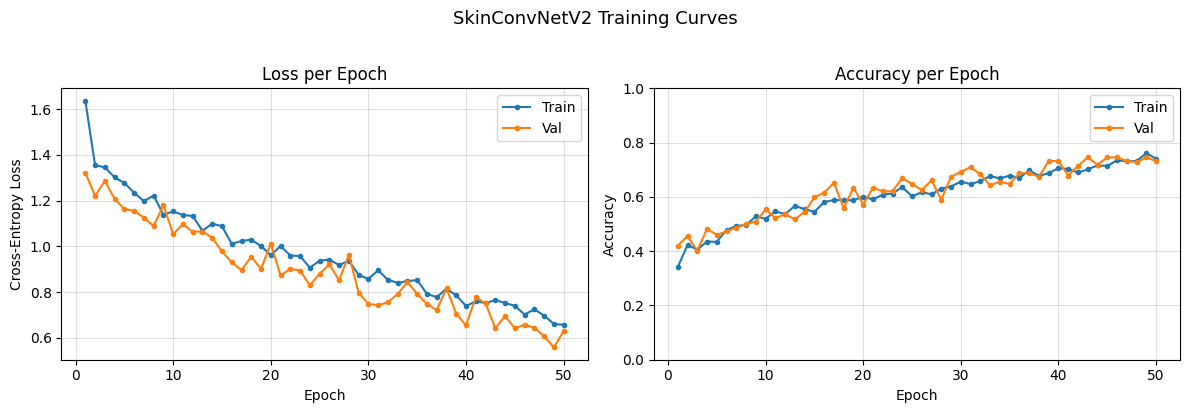

Final Train Accuracy : 0.741
Final Val   Accuracy : 0.732


In [11]:
import matplotlib.pyplot as plt

# x-axis: epoch numbers starting from 1
epochs = range(1, len(history["train_loss"]) + 1)

# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# ── Left plot: Loss curves ─────────────────────────────────────────────────────
# A well-trained model shows both curves decreasing and converging.
ax1.plot(epochs, history["train_loss"], label="Train", marker="o", markersize=3)
ax1.plot(epochs, history["val_loss"],   label="Val",   marker="o", markersize=3)
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-Entropy Loss")
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Right plot: Accuracy curves ───────────────────────────────────────────────
# A well-trained model shows accuracy increasing and train ≈ val accuracy.
ax2.plot(epochs, history["train_acc"], label="Train", marker="o", markersize=3)
ax2.plot(epochs, history["val_acc"],   label="Val",   marker="o", markersize=3)
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)   # accuracy is always between 0 and 1
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle("SkinConvNetV2 Training Curves", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print final metrics
print(f"Final Train Accuracy : {history['train_acc'][-1]:.3f}")
print(f"Final Val   Accuracy : {history['val_acc'][-1]:.3f}")

---
## 10. Test Set Evaluation

The test set is held out entirely during training and hyperparameter tuning.  
It gives an **unbiased estimate** of how the model will perform on truly unseen data.

> **Important:** Only evaluate on the test set once — after all design decisions are finalised.  
> If you use test performance to make decisions, it leaks into your training process and the estimate is no longer unbiased.

In [12]:
# ── Final evaluation on the held-out test set ─────────────────────────────────
model.eval()   # disable Dropout, use BatchNorm running stats
test_correct = 0

with torch.no_grad():           # no gradient computation needed
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs    = model(imgs)
        test_correct += (outputs.argmax(1) == lbls).sum().item()

test_acc = test_correct / len(test_loader.dataset)
print(f"Test Accuracy: {test_acc:.4f}  ({test_correct}/{len(test_loader.dataset)} correct)")

Test Accuracy: 0.6978  (157/225 correct)


---
## 11. Beyond Accuracy — Classification Metrics

Accuracy alone can be misleading, especially when classes are **imbalanced** (e.g., one class has 10× more samples than another).  
A model that predicts the majority class every time can achieve high accuracy while being useless.

### Key Metrics

| Metric | Formula | What It Measures |
|---|---|---|
| **Precision** | $\frac{TP}{TP + FP}$ | Of everything predicted as class C, how many are actually C? |
| **Recall** (Sensitivity) | $\frac{TP}{TP + FN}$ | Of everything that is truly class C, how many were found? |
| **F1 Score** | $\frac{2 \cdot P \cdot R}{P + R}$ | Harmonic mean of precision and recall — good for imbalanced data |
| **Macro F1** | Mean F1 across all classes | Treats all classes equally regardless of size |
| **Weighted F1** | F1 weighted by class support | Accounts for class imbalance |
| **Cohen's κ** | Agreement beyond chance | Useful when class sizes differ greatly |

### Confusion Matrix

A confusion matrix shows **where the model makes mistakes** — which classes get confused with which.  
Perfect classification = diagonal matrix.

$$C_{ij} = \text{number of samples truly in class } i \text{ predicted as class } j$$

### ROC-AUC (One-vs-Rest)

For multi-class problems, ROC curves are computed with a **one-vs-rest** strategy:  
each class is treated as the positive class while all others are negative.  
AUC = 1.0 is perfect; AUC = 0.5 is random chance.

In [13]:
# ── Step 1: Collect all predictions and ground-truth labels from the test set ──
# We need the raw arrays to feed into sklearn's metric functions.
# We also collect predicted probabilities for ROC-AUC.

import numpy as np

model.eval()
all_labels  = []   # true integer class indices
all_preds   = []   # predicted class indices (argmax)
all_probs   = []   # softmax probabilities for each class (needed for ROC-AUC)

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)                          # raw logits [B, C]

        probs = torch.softmax(outputs, dim=1)          # convert logits → probabilities
        preds = outputs.argmax(dim=1)                  # predicted class index

        all_labels.extend(lbls.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)   # shape: (N,)
all_preds  = np.array(all_preds)    # shape: (N,)
all_probs  = np.array(all_probs)    # shape: (N, num_classes)

print(f"Collected {len(all_labels)} test samples")
print(f"Class names: {train_ds.classes}")

Collected 225 test samples
Class names: ['acne', 'eksim', 'herpes', 'panu', 'rosacea']


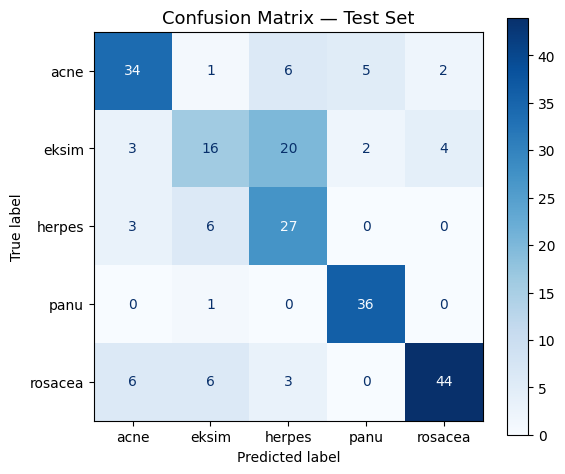

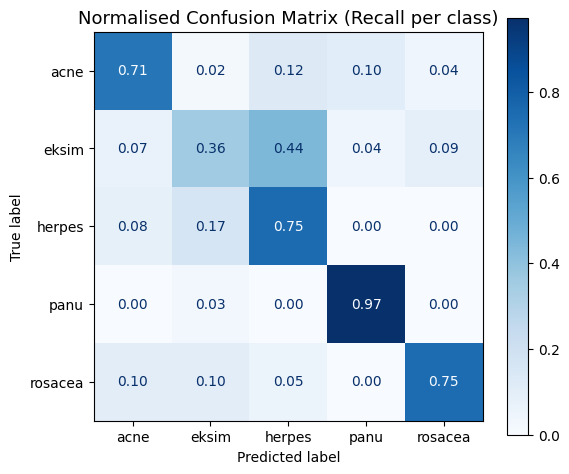

In [14]:
# ── Step 2: Confusion Matrix ──────────────────────────────────────────────────
# Rows = true classes, Columns = predicted classes.
# A perfect classifier produces a pure diagonal matrix.

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_ds.classes)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set", fontsize=13)
plt.tight_layout()
plt.show()

# ── Normalised confusion matrix (row-wise: fraction of true class) ────────────
cm_norm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=train_ds.classes)
disp_norm.plot(ax=ax, colorbar=True, cmap="Blues", values_format=".2f")
ax.set_title("Normalised Confusion Matrix (Recall per class)", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# ── Step 3: Precision, Recall, F1 Score & Classification Report ───────────────
# classification_report prints per-class and aggregate metrics in one call.

from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    cohen_kappa_score,
    balanced_accuracy_score,
)

# ── Per-class and aggregate metrics ──────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
# zero_division=0 avoids warnings if a class is never predicted
print(classification_report(
    all_labels, all_preds,
    target_names=train_ds.classes,
    zero_division=0,
))

# ── Scalar summary metrics ────────────────────────────────────────────────────
print("=" * 60)
print("AGGREGATE METRICS")
print("=" * 60)

accuracy_overall  = (all_preds == all_labels).mean()
balanced_acc      = balanced_accuracy_score(all_labels, all_preds)    # avg recall per class
macro_f1          = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
weighted_f1       = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
macro_precision   = precision_score(all_labels, all_preds, average="macro",    zero_division=0)
macro_recall      = recall_score(all_labels, all_preds,    average="macro",    zero_division=0)
kappa             = cohen_kappa_score(all_labels, all_preds)           # agreement beyond chance

print(f"  Accuracy (overall)      : {accuracy_overall:.4f}")
print(f"  Balanced Accuracy       : {balanced_acc:.4f}  ← better metric for imbalanced data")
print(f"  Macro Precision         : {macro_precision:.4f}")
print(f"  Macro Recall            : {macro_recall:.4f}")
print(f"  Macro F1                : {macro_f1:.4f}  ← treats all classes equally")
print(f"  Weighted F1             : {weighted_f1:.4f}  ← weighted by class support")
print(f"  Cohen's Kappa           : {kappa:.4f}  ← 1.0=perfect, 0.0=chance")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acne       0.74      0.71      0.72        48
       eksim       0.53      0.36      0.43        45
      herpes       0.48      0.75      0.59        36
        panu       0.84      0.97      0.90        37
     rosacea       0.88      0.75      0.81        59

    accuracy                           0.70       225
   macro avg       0.69      0.71      0.69       225
weighted avg       0.71      0.70      0.69       225

AGGREGATE METRICS
  Accuracy (overall)      : 0.6978
  Balanced Accuracy       : 0.7065  ← better metric for imbalanced data
  Macro Precision         : 0.6944
  Macro Recall            : 0.7065
  Macro F1                : 0.6889  ← treats all classes equally
  Weighted F1             : 0.6933  ← weighted by class support
  Cohen's Kappa           : 0.6223  ← 1.0=perfect, 0.0=chance


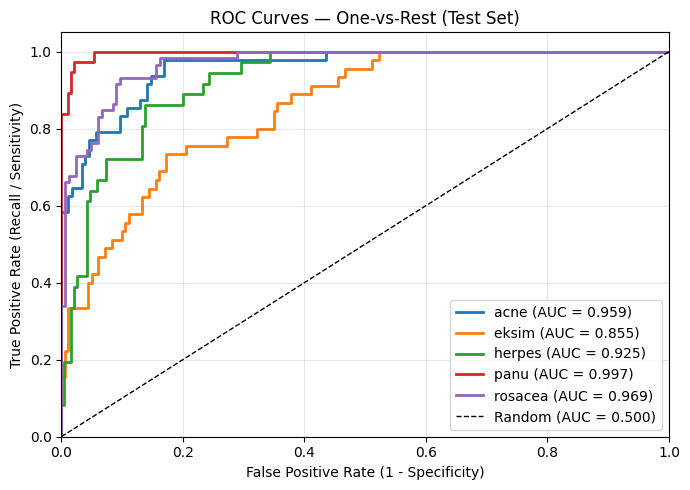

Macro-average ROC AUC    : 0.9410
Weighted-average ROC AUC : 0.9416


In [16]:
# ── Step 4: ROC Curves & AUC (One-vs-Rest) ───────────────────────────────────
# For multi-class problems we compute one ROC curve per class using a
# one-vs-rest (OvR) strategy: class i is "positive", all others are "negative".
# AUC (Area Under the Curve) summarises the whole curve in one number:
#   AUC = 1.0 → perfect classifier
#   AUC = 0.5 → random chance

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarise labels: shape (N, num_classes) — one-hot style
classes_range   = list(range(num_classes))
labels_binarized = label_binarize(all_labels, classes=classes_range)  # shape (N, C)

fig, ax = plt.subplots(figsize=(7, 5))

for i, class_name in enumerate(train_ds.classes):
    # ROC curve for class i treating it as the positive class
    fpr, tpr, _ = roc_curve(labels_binarized[:, i], all_probs[:, i])
    roc_auc      = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_name} (AUC = {roc_auc:.3f})")

# Diagonal = random-chance baseline
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.500)")

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)")
ax.set_title("ROC Curves — One-vs-Rest (Test Set)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Macro-average ROC AUC ─────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(labels_binarized, all_probs, average="macro",    multi_class="ovr")
weighted_auc = roc_auc_score(labels_binarized, all_probs, average="weighted", multi_class="ovr")
print(f"Macro-average ROC AUC    : {macro_auc:.4f}")
print(f"Weighted-average ROC AUC : {weighted_auc:.4f}")

---
## Summary & Next Steps

### What We Built

```
Raw Images → Custom Dataset → DataLoader → CNN Model → Predictions
                                              ↑
                                    (trained with Adam + CrossEntropyLoss)
```

### Key Concepts Covered

| Concept | PyTorch API |
|---|---|
| GPU acceleration | `torch.device`, `.to(device)` |
| Model definition | `nn.Module`, `nn.Sequential` |
| Layer types | `Conv2d`, `BatchNorm2d`, `ReLU`, `MaxPool2d`, `Linear`, `Dropout` |
| Transfer Learning | `torchvision.models.resnet18(weights=…)` |
| Custom dataset | `Dataset.__len__`, `Dataset.__getitem__` |
| Data pipeline | `transforms.Compose`, `DataLoader` |
| Training loop | `loss.backward()`, `optimizer.step()`, `model.train()`, `model.eval()` |
| Gradient saving | `torch.no_grad()` |

### Things to Try

1. **Swap the model** — replace `SkinConvNetV2` with `SkinLesionResNet` and compare results.
2. **Tune the learning rate** — try `lr=1e-4` vs `lr=1e-2` and observe the effect on curves.
3. **Add a learning rate scheduler** — `torch.optim.lr_scheduler.StepLR` decays the LR every N epochs.
4. **Add class-weighted loss** — if the dataset is imbalanced, pass `weight=` to `nn.CrossEntropyLoss`.
5. **Early stopping** — save the model weights when val loss is at its lowest.